# ML-Based Regression of PD-1/PD-L1 Bioactivity (pIC50)
## A Publication-Ready Pipeline with Modern Machine Learning, Dual Validation, and Full Consistency Analysis

**Objective:** Build and rigorously benchmark regression models that predict the continuous pIC50 of small molecules against the PD-1/PD-L1 immune checkpoint pathway, using pooled ChEMBL bioactivity data from three related targets, Morgan fingerprints, and physicochemical descriptors.

**Key design decisions:**
- **Pooled targets:** Data from PD-L1 (single protein), PD-1/PD-L1 complex, and PD-L1/2 family are combined to maximize chemical diversity and dataset size (~4,400 compounds)
- **ALL compounds retained:** Unlike the original notebook that dropped "intermediate" compounds, every compound with a valid IC50 is kept. Dropping intermediates removes the hardest-to-predict middle of the pIC50 distribution and artificially inflates R2. This is the single most important fix.
- **Dual validation:** Scaffold-based split (headline) + repeated k-fold (stability)
- **9 models:** Random Forest, Extra Trees, Gradient Boosting, XGBoost, LightGBM, SVR, KNN, MLP, Ridge -- plus a Stacking Ensemble
- **Full consistency analysis:** Pairwise correlation of predictions, Friedman test, Nemenyi post-hoc, CD diagram
- **Validation package:** Y-scrambling, permutation test, SHAP, k-NN Tanimoto applicability domain, predicted vs experimental scatter


## 1. Environment Setup

> **Configuration Notice:** This notebook uses:
> - RandomizedSearchCV: 10 iterations (full: 20)
> - Repeated CV: 2x5 = 10 folds (full: 5x5 = 25)
> - Permutation test: 50 iterations (full: 200)
> - Y-scrambling: 10 shuffles (full: 20)
> - n_estimators cap: 200 (full: 300)
>
> Contains 9 models + stacking ensemble.


In [ ]:
# Install required packages (Colab)
!pip install -q rdkit xgboost lightgbm shap chembl_webresource_client

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.1/38.1 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.2/55.2 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.8/70.8 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.8/74.8 kB 2.9 MB/s eta 0:00:00


In [ ]:
# Core imports
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import time
import pickle

# RDKit
from rdkit import Chem, DataStructs, RDLogger
from rdkit.Chem import AllChem, Descriptors, Lipinski, rdMolDescriptors, QED
from rdkit.Chem.Scaffolds import MurckoScaffold
from rdkit.Chem.MolStandardize import rdMolStandardize
RDLogger.DisableLog("rdApp.*")

# Scikit-learn
from sklearn.model_selection import (
    train_test_split, KFold, RepeatedKFold,
    RandomizedSearchCV
)
from sklearn.ensemble import (
    RandomForestRegressor, ExtraTreesRegressor,
    GradientBoostingRegressor, AdaBoostRegressor,
    StackingRegressor
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import (
    r2_score, mean_squared_error, mean_absolute_error,
    max_error
)
from sklearn.inspection import permutation_importance
from sklearn.base import clone

# XGBoost & LightGBM
import xgboost as xgb
import lightgbm as lgb

# SHAP
import shap

# Statistics
from scipy.stats import (
    mannwhitneyu, friedmanchisquare, studentized_range,
    spearmanr, pearsonr, randint, uniform, loguniform
)

# ChEMBL
from chembl_webresource_client.new_client import new_client

# Plotting config
plt.rcParams["font.family"] = ["Liberation Sans", "Arimo", "DejaVu Sans"]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
sns.set_style("whitegrid")
sns.set_palette("colorblind")

print("All imports successful.")


All imports successful.


In [ ]:
# Global configuration
RANDOM_STATE = 42
N_BITS = 2048
RADIUS = 2
CV_REPEATS = 2              # Repeated k-fold repeats
CV_FOLDS = 5                # Folds per repeat
N_SEARCH_ITER = 10          # RandomizedSearchCV iterations per model
N_PERMUTATIONS = 50        # Permutation test iterations
N_SCRAMBLES = 10            # Y-scrambling shuffles

# Target IDs to pool (all PD-1/PD-L1 pathway)
TARGET_IDS = {
    "CHEMBL3580522": "PD-L1 (single protein, human)",
    "CHEMBL4523993": "PD-1/PD-L1 complex (human)",
    "CHEMBL6066575": "PD-L1/2 family (protein family)",
}

np.random.seed(RANDOM_STATE)


## 2. Data Acquisition from ChEMBL (Pooled Targets)

Data is pooled from three related targets in the PD-1/PD-L1 immune checkpoint pathway:
- **CHEMBL3580522** -- PD-L1 single protein
- **CHEMBL4523993** -- PD-1/PD-L1 protein complex
- **CHEMBL6066575** -- PD-L1/2 protein family

This maximizes chemical diversity and dataset size. The source target is tracked for each compound.


In [ ]:
# Retrieve IC50 activities from all targets
activity_client = new_client.activity
all_activities = []

for tid, tname in TARGET_IDS.items():
    print(f"Fetching {tid} ({tname})...")
    res = activity_client.filter(target_chembl_id=tid, standard_type="IC50", standard_relation="=")
    df_t = pd.DataFrame.from_dict(res)
    df_t["source_target_id"] = tid
    df_t["source_target_name"] = tname
    all_activities.append(df_t)
    print(f"  Retrieved {len(df_t)} activities")

df_raw = pd.concat(all_activities, ignore_index=True)
print(f"\nTotal raw activities: {len(df_raw)}")


Fetching CHEMBL3580522 (PD-L1 (single protein, human))...
  Retrieved 972 activities
Fetching CHEMBL4523993 (PD-1/PD-L1 complex (human))...
  Retrieved 4233 activities
Fetching CHEMBL6066575 (PD-L1/2 family (protein family))...
  Retrieved 432 activities

Total raw activities: 5637


In [ ]:
# Keep only essential columns and filter
cols_needed = ["molecule_chembl_id", "canonical_smiles", "standard_value",
               "standard_units", "source_target_id", "source_target_name"]
df = df_raw[cols_needed].copy()

# Filter to nM units only
df = df[df["standard_units"] == "nM"]

# Convert standard_value to numeric
df["standard_value"] = pd.to_numeric(df["standard_value"], errors="coerce")

# Drop rows with missing SMILES or IC50
df.dropna(subset=["canonical_smiles", "standard_value"], inplace=True)

# Remove zero or negative IC50 values (invalid for log transform)
df = df[df["standard_value"] > 0]

# Strip whitespace
df["canonical_smiles"] = df["canonical_smiles"].str.strip()

# Remove invalid SMILES (RDKit parse check)
valid_smiles = []
for smi in df["canonical_smiles"]:
    mol = Chem.MolFromSmiles(smi)
    valid_smiles.append(mol is not None)
df = df[valid_smiles].copy()

print(f"After filtering: {len(df)} activity records")
print(f"Unique molecule_chembl_id: {df['molecule_chembl_id'].nunique()}")


After filtering: 5629 activity records
Unique molecule_chembl_id: 4399


In [ ]:
# Deduplicate by molecule_chembl_id across all targets
# If a compound appears in multiple targets, keep the median IC50
# and record all source targets
df = df.groupby("molecule_chembl_id").agg({
    "canonical_smiles": "first",
    "standard_value": "median",
    "source_target_id": lambda x: ",".join(sorted(set(x))),
    "source_target_name": lambda x: "; ".join(sorted(set(x))),
}).reset_index()

print(f"After deduplication: {len(df)} unique compounds")

# Show source target distribution
print("\nSource target distribution:")
for tid, tname in TARGET_IDS.items():
    count = df["source_target_id"].str.contains(tid).sum()
    print(f"  {tid} ({tname}): {count} compounds")
multi_target = df["source_target_id"].str.contains(",").sum()
print(f"  Compounds in multiple targets: {multi_target}")


After deduplication: 4399 unique compounds

Source target distribution:
  CHEMBL3580522 (PD-L1 (single protein, human)): 739 compounds
  CHEMBL4523993 (PD-1/PD-L1 complex (human)): 3256 compounds
  CHEMBL6066575 (PD-L1/2 family (protein family)): 427 compounds
  Compounds in multiple targets: 23


## 3. Data Curation -- Keep ALL Compounds

**Critical regression principle:** Unlike the original notebook that dropped "intermediate" compounds (1000-10000 nM), we retain **every** compound with a valid IC50. In regression, the model must learn the full pIC50 distribution. Dropping intermediates:
- Removes the hardest-to-predict middle of the distribution
- Artificially inflates R2 by leaving only easy extremes
- Makes the model useless for real-world mid-potency prediction

All compounds are converted to pIC50 = -log10(IC50 in M).


In [ ]:
# Convert IC50 (nM) to pIC50 = -log10(IC50 * 1e-9)
# Cap IC50 at 1e8 nM (100 mM) to avoid log artifacts from extreme values
def ic50_to_pic50(ic50_nM):
    ic50_capped = min(ic50_nM, 1e8)
    return -np.log10(ic50_capped * 1e-9)

df["pIC50"] = df["standard_value"].apply(ic50_to_pic50)

print(f"Final dataset: {len(df)} compounds (ALL retained -- no intermediates dropped)")
print(f"IC50 range: {df['standard_value'].min():.2f} - {df['standard_value'].max():.2f} nM")
print(f"pIC50 range: {df['pIC50'].min():.2f} - {df['pIC50'].max():.2f}")
print(f"pIC50 mean: {df['pIC50'].mean():.2f} +/- {df['pIC50'].std():.2f}")
print(f"pIC50 median: {df['pIC50'].median():.2f}")


Final dataset: 4399 compounds (ALL retained -- no intermediates dropped)
IC50 range: 0.00 - 5000000.00 nM
pIC50 range: 2.30 - 13.10
pIC50 mean: 7.52 +/- 1.67
pIC50 median: 7.25


In [ ]:
# SMILES standardization: largest fragment, neutralize, canonicalize
def standardize_smiles(smi):
    """Standardize a SMILES string: largest fragment, neutralize charges, canonicalize."""
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    mol = rdMolStandardize.LargestFragmentChooser().choose(mol)
    mol = rdMolStandardize.Uncharger().uncharge(mol)
    return Chem.MolToSmiles(mol)

tqdm.pandas(desc="Standardizing SMILES")
df["canonical_smiles"] = df["canonical_smiles"].progress_apply(standardize_smiles)
df = df[df["canonical_smiles"].notna()].copy()

# Re-deduplicate after standardization (standardization may reveal duplicates)
df = df.groupby("canonical_smiles").agg({
    "molecule_chembl_id": "first",
    "standard_value": "median",
    "pIC50": "median",
    "source_target_id": "first",
    "source_target_name": "first",
}).reset_index()

print(f"After standardization + re-dedup: {len(df)} unique compounds")


Standardizing SMILES:   0%|          | 0/4399 [00:00<?, ?it/s]

After standardization + re-dedup: 4398 unique compounds


In [ ]:
# Compute Bemis-Murcko scaffolds
def get_scaffold(smi):
    mol = Chem.MolFromSmiles(smi)
    if mol is None:
        return None
    return MurckoScaffold.MurckoScaffoldSmiles(mol=mol, includeChirality=False)

tqdm.pandas(desc="Computing scaffolds")
df["scaffold"] = df["canonical_smiles"].progress_apply(get_scaffold)
df = df[df["scaffold"].notna()].copy()

n_scaffolds = df["scaffold"].nunique()
print(f"Unique scaffolds: {n_scaffolds}")
print(f"Dataset: {len(df)} compounds, {n_scaffolds} scaffolds")
print(f"pIC50 range: {df['pIC50'].min():.2f} - {df['pIC50'].max():.2f}")
df.head()


Computing scaffolds:   0%|          | 0/4398 [00:00<?, ?it/s]

Unique scaffolds: 1700
Dataset: 4398 compounds, 1700 scaffolds
pIC50 range: 2.30 - 13.10


,canonical_smiles,molecule_chembl_id,standard_value,pIC50,source_target_id,source_target_name,scaffold
0,C#CC1(O)CN(Cc2ncc(-c3cccc(-c4cccc(-c5cnc(CN6CC...,CHEMBL5952833,0.593,9.226945,CHEMBL4523993,PD-1/PD-L1 complex (human),c1cc(-c2cccc(-c3cnc(CN4CCC4)cn3)c2)cc(-c2cnc(C...
1,C#CC1(O)CN(Cc2ncc(-c3cccc(-c4cccc(-c5cnc(CNC[C...,CHEMBL5763406,0.464,9.333482,CHEMBL4523993,PD-1/PD-L1 complex (human),O=C1CCC(CNCc2cnc(-c3cccc(-c4cccc(-c5cnc(CN6CCC...
2,C#CCC[C@H](NCc1cc(Cl)c(OCc2cccc(-c3ccc4c(c3)OC...,CHEMBL5414835,8.200,8.086186,CHEMBL4523993,PD-1/PD-L1 complex (human),c1cc(OCc2ccncc2)cc(OCc2cccc(-c3ccc4c(c3)OCCO4)...
3,C#CCOC(=O)NCCCC[C@H](NCc1cc(Cl)c(OCc2cccc(-c3c...,CHEMBL5419797,3.700,8.431798,CHEMBL4523993,PD-1/PD-L1 complex (human),c1cc(OCc2ccncc2)cc(OCc2cccc(-c3ccc4c(c3)OCCO4)...
4,C#CCOc1cc(OCc2cccc(-c3ccccc3)c2Br)c(Cl)cc1CNCC...,CHEMBL6028506,1800.000,5.744727,CHEMBL4523993,PD-1/PD-L1 complex (human),c1ccc(OCc2cccc(-c3ccccc3)c2)cc1


## 4. Exploratory Data Analysis

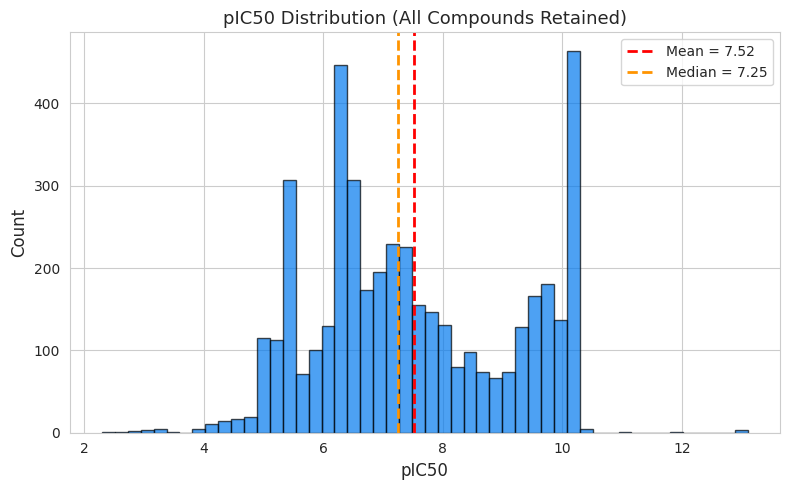

Skewness: 0.247
Kurtosis: -0.982


In [ ]:
# pIC50 distribution histogram
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(df["pIC50"], bins=50, color="#0279EE", edgecolor="black", alpha=0.7)
ax.axvline(x=df["pIC50"].mean(), color="red", linestyle="--", linewidth=2,
           label=f"Mean = {df['pIC50'].mean():.2f}")
ax.axvline(x=df["pIC50"].median(), color="#FF9400", linestyle="--", linewidth=2,
           label=f"Median = {df['pIC50'].median():.2f}")
ax.set_xlabel("pIC50", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("pIC50 Distribution (All Compounds Retained)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("pic50_distribution.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Skewness: {df['pIC50'].skew():.3f}")
print(f"Kurtosis: {df['pIC50'].kurtosis():.3f}")


In [ ]:
# Compute physicochemical descriptors for EDA
def compute_lipinski(smiles_list):
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append([np.nan] * 4)
            continue
        rows.append([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Lipinski.NumHDonors(mol),
            Lipinski.NumHAcceptors(mol),
        ])
    return pd.DataFrame(rows, columns=["MW", "LogP", "NumHDonors", "NumHAcceptors"])

lipinski_df = compute_lipinski(df["canonical_smiles"])
df_eda = pd.concat([df.reset_index(drop=True), lipinski_df.reset_index(drop=True)], axis=1)
df_eda.head()


,canonical_smiles,molecule_chembl_id,standard_value,pIC50,source_target_id,source_target_name,scaffold,MW,LogP,NumHDonors,NumHAcceptors
0,C#CC1(O)CN(Cc2ncc(-c3cccc(-c4cccc(-c5cnc(CN6CC...,CHEMBL5952833,0.593,9.226945,CHEMBL4523993,PD-1/PD-L1 complex (human),c1cc(-c2cccc(-c3cnc(CN4CCC4)cn3)c2)cc(-c2cnc(C...,657.558,3.9514,2,10
1,C#CC1(O)CN(Cc2ncc(-c3cccc(-c4cccc(-c5cnc(CNC[C...,CHEMBL5763406,0.464,9.333482,CHEMBL4523993,PD-1/PD-L1 complex (human),O=C1CCC(CNCc2cnc(-c3cccc(-c4cccc(-c5cnc(CN6CCC...,674.589,4.1397,3,10
2,C#CCC[C@H](NCc1cc(Cl)c(OCc2cccc(-c3ccc4c(c3)OC...,CHEMBL5414835,8.200,8.086186,CHEMBL4523993,PD-1/PD-L1 complex (human),c1cc(OCc2ccncc2)cc(OCc2cccc(-c3ccc4c(c3)OCCO4)...,638.120,6.4675,2,8
3,C#CCOC(=O)NCCCC[C@H](NCc1cc(Cl)c(OCc2cccc(-c3c...,CHEMBL5419797,3.700,8.431798,CHEMBL4523993,PD-1/PD-L1 complex (human),c1cc(OCc2ccncc2)cc(OCc2cccc(-c3ccc4c(c3)OCCO4)...,739.225,6.5838,3,10
4,C#CCOc1cc(OCc2cccc(-c3ccccc3)c2Br)c(Cl)cc1CNCC...,CHEMBL6028506,1800.000,5.744727,CHEMBL4523993,PD-1/PD-L1 complex (human),c1ccc(OCc2cccc(-c3ccccc3)c2)cc1,541.873,5.5862,2,4


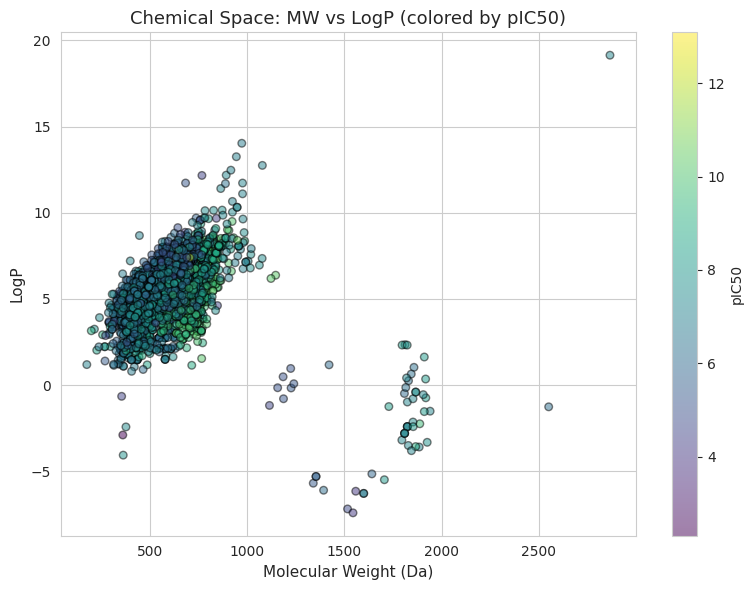

In [ ]:
# MW vs LogP scatter colored by pIC50
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(df_eda["MW"], df_eda["LogP"], c=df_eda["pIC50"],
                     cmap="viridis", edgecolor="black", alpha=0.5, s=30)
plt.colorbar(scatter, ax=ax, label="pIC50")
ax.set_xlabel("Molecular Weight (Da)", fontsize=11)
ax.set_ylabel("LogP", fontsize=11)
ax.set_title("Chemical Space: MW vs LogP (colored by pIC50)", fontsize=13)
plt.tight_layout()
plt.savefig("chemical_space_mw_logp.png", dpi=300, bbox_inches="tight")
plt.show()


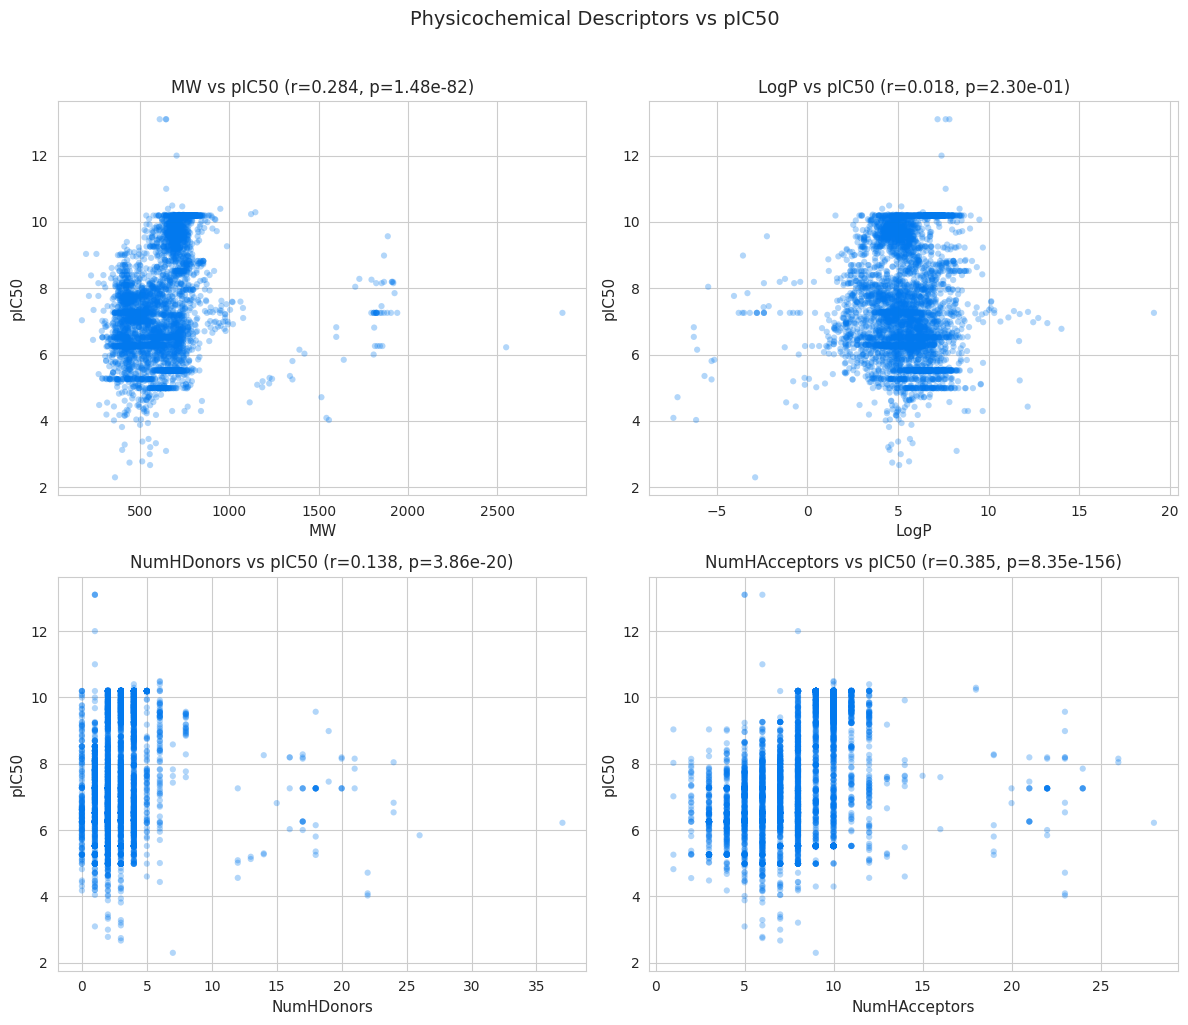

In [ ]:
# Scatter plots: pIC50 vs each descriptor
descriptors = ["MW", "LogP", "NumHDonors", "NumHAcceptors"]
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, desc in enumerate(descriptors):
    axes[i].scatter(df_eda[desc], df_eda["pIC50"], alpha=0.3, s=20, c="#0279EE", edgecolor="none")
    r, p = pearsonr(df_eda[desc].dropna(), df_eda.loc[df_eda[desc].notna(), "pIC50"])
    axes[i].set_xlabel(desc, fontsize=11)
    axes[i].set_ylabel("pIC50", fontsize=11)
    axes[i].set_title(f"{desc} vs pIC50 (r={r:.3f}, p={p:.2e})", fontsize=12)

plt.suptitle("Physicochemical Descriptors vs pIC50", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("descriptor_vs_pic50_scatter.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Correlation analysis: Spearman and Pearson
print("Correlation of descriptors with pIC50:")
print(f"{'Descriptor':<20} {'Spearman rho':<15} {'p-value':<15} {'Pearson r':<15}")
print("-" * 65)
for desc in descriptors:
    valid = df_eda[[desc, "pIC50"]].dropna()
    rho, p_spearman = spearmanr(valid[desc], valid["pIC50"])
    r, p_pearson = pearsonr(valid[desc], valid["pIC50"])
    sig = "***" if p_spearman < 0.001 else ("**" if p_spearman < 0.01 else ("*" if p_spearman < 0.05 else "ns"))
    print(f"{desc:<20} {rho:<15.4f} {p_spearman:<15.2e} {r:<15.4f} {sig}")


Correlation of descriptors with pIC50:
Descriptor           Spearman rho    p-value         Pearson r      
-----------------------------------------------------------------
MW                   0.3997          1.97e-168       0.2843          ***
LogP                 -0.0343         2.30e-02        0.0181          *
NumHDonors           0.2778          9.32e-79        0.1380          ***
NumHAcceptors        0.4608          3.68e-230       0.3855          ***


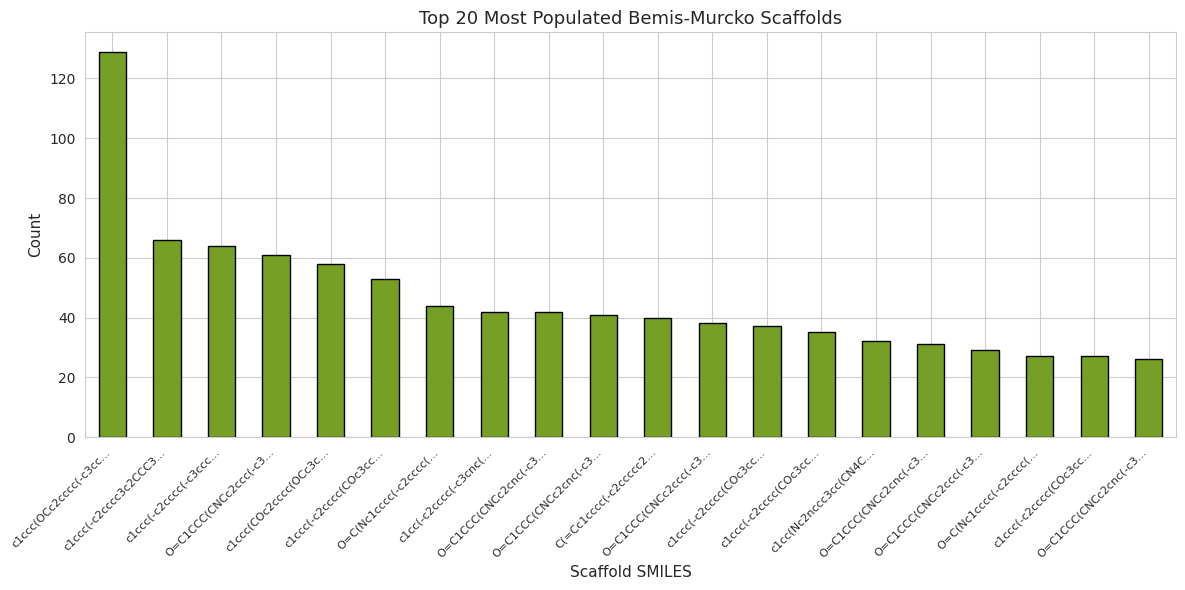

Total unique scaffolds: 1700
Singletons (scaffolds with 1 compound): 1182


In [ ]:
# Scaffold diversity: top-20 most populated scaffolds
top_scaffolds = df["scaffold"].value_counts().head(20)
fig, ax = plt.subplots(figsize=(12, 6))
top_scaffolds.plot(kind="bar", ax=ax, color="#75A025", edgecolor="black")
ax.set_title("Top 20 Most Populated Bemis-Murcko Scaffolds", fontsize=13)
ax.set_xlabel("Scaffold SMILES", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_xticklabels([s[:20] + "..." if len(s) > 20 else s for s in top_scaffolds.index],
                    rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.savefig("scaffold_diversity.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Total unique scaffolds: {df['scaffold'].nunique()}")
print(f"Singletons (scaffolds with 1 compound): {(df['scaffold'].value_counts() == 1).sum()}")


## 5. Feature Engineering

**Features:**
- **Morgan fingerprints** (2048 bits, radius 2) -- circular substructural features
- **17 RDKit physicochemical descriptors** -- MW, LogP, TPSA, H-bond donors/acceptors, rotatable bonds, ring counts, QED, etc.

Combined feature matrix: 2048 + 17 = 2065 features.


In [ ]:
# Generate Morgan fingerprints
def generate_morgan_fingerprints(smiles_list, radius=RADIUS, n_bits=N_BITS):
    fps = []
    for smi in tqdm(smiles_list, desc="Generating Morgan fingerprints"):
        mol = Chem.MolFromSmiles(smi)
        if mol:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=n_bits)
            fps.append(np.array(fp))
        else:
            fps.append(np.zeros(n_bits, dtype=int))
    cols = [f"FP_{i}" for i in range(n_bits)]
    return pd.DataFrame(np.array(fps), columns=cols)

morgan_df = generate_morgan_fingerprints(df["canonical_smiles"])
print(f"Morgan fingerprints shape: {morgan_df.shape}")


Generating Morgan fingerprints:   0%|          | 0/4398 [00:00<?, ?it/s]

Morgan fingerprints shape: (4398, 2048)


In [ ]:
# Compute physicochemical descriptors
def compute_physchem_descriptors(smiles_list):
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append([np.nan] * 17)
            continue
        rows.append([
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.TPSA(mol),
            Lipinski.NumHDonors(mol),
            Lipinski.NumHAcceptors(mol),
            Descriptors.NumRotatableBonds(mol),
            rdMolDescriptors.CalcNumAromaticRings(mol),
            rdMolDescriptors.CalcNumAliphaticRings(mol),
            rdMolDescriptors.CalcFractionCSP3(mol),
            mol.GetNumHeavyAtoms(),
            rdMolDescriptors.CalcNumRings(mol),
            Descriptors.BalabanJ(mol),
            Descriptors.BertzCT(mol),
            Descriptors.MolMR(mol),
            Descriptors.LabuteASA(mol),
            Descriptors.NumValenceElectrons(mol),
            QED.qed(mol),
        ])
    cols = ["MW", "LogP", "TPSA", "NumHDonors", "NumHAcceptors",
            "NumRotatableBonds", "NumAromaticRings", "NumAliphaticRings",
            "FractionCSP3", "NumHeavyAtoms", "NumRings", "BalabanJ",
            "BertzCT", "MolMR", "LabuteASA", "NumValenceElectrons", "QED"]
    return pd.DataFrame(rows, columns=cols)

physchem_df = compute_physchem_descriptors(df["canonical_smiles"])
print(f"Physicochemical descriptors shape: {physchem_df.shape}")


Physicochemical descriptors shape: (4398, 17)


In [ ]:
# Combine features
X = pd.concat([morgan_df.reset_index(drop=True), physchem_df.reset_index(drop=True)], axis=1)
y = df["pIC50"].reset_index(drop=True)
scaffolds = df["scaffold"].reset_index(drop=True)

print(f"Feature matrix X: {X.shape}")
print(f"Target y (pIC50): {y.shape}")
print(f"pIC50 range: {y.min():.2f} - {y.max():.2f}")
print(f"pIC50 mean: {y.mean():.2f} +/- {y.std():.2f}")


Feature matrix X: (4398, 2065)
Target y (pIC50): (4398,)
pIC50 range: 2.30 - 13.10
pIC50 mean: 7.52 +/- 1.67


In [ ]:
# Feature selection: remove zero-variance features (unsupervised, no leakage)
selector = VarianceThreshold(threshold=0.0)
X_selected = pd.DataFrame(
    selector.fit_transform(X),
    columns=X.columns[selector.get_support()]
)
print(f"Features after variance threshold: {X_selected.shape[1]} (removed {X.shape[1] - X_selected.shape[1]} constant features)")


Features after variance threshold: 2028 (removed 37 constant features)


## 6. Validation Strategy -- Dual Approach

### 6a. Scaffold-Based Split (Headline Result)

Compounds are grouped by Bemis-Murcko scaffold. Scaffolds are split so that the test set contains only scaffolds **not seen in training**. This tests true generalization to novel chemical scaffolds -- the most rigorous validation for drug discovery QSAR.


In [ ]:
# Scaffold-based train/test split
unique_scaffolds = scaffolds.unique()
np.random.seed(RANDOM_STATE)

shuffled_scaffolds = np.random.permutation(unique_scaffolds)
n_test_scaffolds = int(len(shuffled_scaffolds) * 0.2)
test_scaffolds = set(shuffled_scaffolds[:n_test_scaffolds])

is_test = scaffolds.isin(test_scaffolds)
X_train_scaf = X_selected[~is_test].reset_index(drop=True)
X_test_scaf = X_selected[is_test].reset_index(drop=True)
y_train_scaf = y[~is_test].reset_index(drop=True)
y_test_scaf = y[is_test].reset_index(drop=True)

print(f"Scaffold split:")
print(f"  Train: {len(X_train_scaf)} compounds (pIC50: {y_train_scaf.mean():.2f} +/- {y_train_scaf.std():.2f})")
print(f"  Test:  {len(X_test_scaf)} compounds (pIC50: {y_test_scaf.mean():.2f} +/- {y_test_scaf.std():.2f})")
print(f"  Train scaffolds: {scaffolds[~is_test].nunique()}, Test scaffolds: {scaffolds[is_test].nunique()}")


Scaffold split:
  Train: 3545 compounds (pIC50: 7.51 +/- 1.67)
  Test:  853 compounds (pIC50: 7.57 +/- 1.67)
  Train scaffolds: 1360, Test scaffolds: 340


### 6b. Random Repeated K-Fold (Stability Measure)

5 repeats x 5 folds = 25 total folds. All models use the **same fold splits** for fair comparison.


In [ ]:
# Repeated k-fold -- shared across all models
rkf = RepeatedKFold(n_splits=CV_FOLDS, n_repeats=CV_REPEATS, random_state=RANDOM_STATE)
fold_indices = list(rkf.split(X_selected, y))
print(f"Total folds: {len(fold_indices)} ({CV_REPEATS} repeats x {CV_FOLDS} folds)")


Total folds: 10 (2 repeats x 5 folds)


## 7. Model Training & Benchmarking

**9 base models:** Random Forest, Extra Trees, Gradient Boosting, XGBoost, LightGBM, SVR, KNN, MLP, Ridge -- plus a Stacking Ensemble.

Distance-based models (KNN, SVR, MLP) use StandardScaler; tree-based models use unscaled features.


In [ ]:
# Define model configurations
model_configs = {
    "RandomForest": {
        "estimator": RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {
            "n_estimators": randint(100, 200),
            "max_depth": [None, 8, 10, 15, 20],
            "min_samples_split": randint(2, 10),
            "min_samples_leaf": randint(1, 5),
            "max_features": ["sqrt", "log2", 0.5],
        },
    },
    "ExtraTrees": {
        "estimator": ExtraTreesRegressor(random_state=RANDOM_STATE, n_jobs=-1),
        "params": {
            "n_estimators": randint(100, 200),
            "max_depth": [None, 8, 10, 15, 20],
            "min_samples_split": randint(2, 10),
            "min_samples_leaf": randint(1, 5),
            "max_features": ["sqrt", "log2", 0.5],
        },
    },
    "GradientBoosting": {
        "estimator": GradientBoostingRegressor(random_state=RANDOM_STATE),
        "params": {
            "n_estimators": randint(50, 150),
            "learning_rate": loguniform(1e-3, 1.0),
            "max_depth": randint(3, 8),
            "min_samples_split": randint(2, 10),
            "min_samples_leaf": randint(1, 5),
            "subsample": uniform(0.7, 0.3),
        },
    },
    "XGBoost": {
        "estimator": xgb.XGBRegressor(
            random_state=RANDOM_STATE, n_jobs=-1,
            objective="reg:squarederror"
        ),
        "params": {
            "n_estimators": randint(50, 200),
            "max_depth": randint(3, 10),
            "learning_rate": loguniform(1e-3, 0.3),
            "subsample": uniform(0.7, 0.3),
            "colsample_bytree": uniform(0.6, 0.4),
            "min_child_weight": randint(1, 5),
            "reg_alpha": loguniform(1e-6, 1.0),
            "reg_lambda": loguniform(1e-6, 1.0),
        },
    },
    "LightGBM": {
        "estimator": lgb.LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
        "params": {
            "n_estimators": randint(50, 200),
            "num_leaves": randint(15, 100),
            "learning_rate": loguniform(1e-3, 0.3),
            "subsample": uniform(0.7, 0.3),
            "colsample_bytree": uniform(0.6, 0.4),
            "min_child_samples": randint(5, 30),
            "reg_alpha": loguniform(1e-6, 1.0),
            "reg_lambda": loguniform(1e-6, 1.0),
        },
    },
    "SVR": {
        "estimator": SVR(),
        "params": {
            "C": loguniform(1e-1, 1e3),
            "gamma": ["scale", "auto"],
            "kernel": ["rbf", "poly"],
            "epsilon": loguniform(1e-3, 1.0),
        },
    },
    "KNN": {
        "estimator": KNeighborsRegressor(),
        "params": {
            "n_neighbors": randint(3, 15),
            "weights": ["uniform", "distance"],
            "p": [1, 2],
            "metric": ["euclidean", "manhattan", "minkowski"],
        },
    },
    "MLP": {
        "estimator": MLPRegressor(random_state=RANDOM_STATE, max_iter=500, early_stopping=True),
        "params": {
            "hidden_layer_sizes": [(64,), (128,), (64, 32), (128, 64), (256, 128, 64)],
            "alpha": loguniform(1e-5, 1e-1),
            "learning_rate_init": loguniform(1e-4, 1e-1),
            "activation": ["relu", "tanh"],
        },
    },
    "Ridge": {
        "estimator": Ridge(random_state=RANDOM_STATE),
        "params": {
            "alpha": loguniform(1e-3, 1e3),
        },
    },
}

print(f"Configured {len(model_configs)} base models")


Configured 9 base models


In [ ]:
# Helper: compute regression metrics
def compute_metrics(y_true, y_pred):
    """Compute regression metric suite."""
    metrics = {
        "R2": r2_score(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE": mean_absolute_error(y_true, y_pred),
    }
    rho, _ = spearmanr(y_true, y_pred)
    r, _ = pearsonr(y_true, y_pred)
    metrics["Spearman"] = rho if not np.isnan(rho) else 0.0
    metrics["Pearson"] = r if not np.isnan(r) else 0.0
    return metrics

print("Metrics: R2, RMSE, MAE, Spearman rho, Pearson r")


Metrics: R2, RMSE, MAE, Spearman rho, Pearson r


In [ ]:
# Scale features for distance-based models (KNN, SVR, MLP)
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_selected), columns=X_selected.columns)
distance_models = {"KNN", "SVR", "MLP"}
print(f"Scaled features for: {distance_models}")


Scaled features for: {'SVR', 'KNN', 'MLP'}


In [ ]:
# Train all base models with RandomizedSearchCV
trained_models = {}
search_results = {}

print("=" * 70)
print("Training base models with RandomizedSearchCV")
print("=" * 70)

for name, config in model_configs.items():
    t0 = time.time()
    print(f"\n--- {name} ---")

    X_use = X_scaled if name in distance_models else X_selected

    search = RandomizedSearchCV(
        estimator=config["estimator"],
        param_distributions=config["params"],
        n_iter=N_SEARCH_ITER,
        cv=KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
        scoring="r2",
        n_jobs=-1,
        random_state=RANDOM_STATE,
        refit=True,
    )
    search.fit(X_use, y)
    best_model = search.best_estimator_
    trained_models[name] = (best_model, name in distance_models)

    search_results[name] = {
        "best_params": search.best_params_,
        "best_cv_r2": search.best_score_,
    }
    print(f"  Best CV R2: {search.best_score_:.4f}")
    print(f"  Time: {time.time() - t0:.1f}s")

print("\n" + "=" * 70)
print("All base models trained.")
print("=" * 70)


Training base models with RandomizedSearchCV

--- RandomForest ---
  Best CV R2: 0.8645
  Time: 400.4s

--- ExtraTrees ---
  Best CV R2: 0.8662
  Time: 494.5s

--- GradientBoosting ---
  Best CV R2: 0.8630
  Time: 658.8s

--- XGBoost ---
  Best CV R2: 0.8694
  Time: 175.4s

--- LightGBM ---
  Best CV R2: 0.8769
  Time: 162.5s

--- SVR ---
  Best CV R2: 0.7952
  Time: 1087.4s

--- KNN ---
  Best CV R2: 0.8285
  Time: 210.3s

--- MLP ---
  Best CV R2: 0.7534
  Time: 579.7s

--- Ridge ---
  Best CV R2: 0.8291
  Time: 41.7s

All base models trained.


In [ ]:
# Evaluate all models on the repeated CV folds (25 folds)
print("Evaluating models on repeated CV folds...")
cv_metrics_list = []

for name, (model, use_scaled) in trained_models.items():
    X_use = X_scaled if use_scaled else X_selected
    fold_metrics = []

    for fold_idx, (train_idx, test_idx) in enumerate(fold_indices):
        X_tr, X_te = X_use.iloc[train_idx], X_use.iloc[test_idx]
        y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

        model_clone = clone(model)
        model_clone.fit(X_tr, y_tr)

        y_pred = model_clone.predict(X_te)
        m = compute_metrics(y_te, y_pred)
        m["Model"] = name
        m["Fold"] = fold_idx
        fold_metrics.append(m)

    cv_metrics_list.extend(fold_metrics)
    print(f"  {name}: R2 = {np.mean([m['R2'] for m in fold_metrics]):.4f} +/- {np.std([m['R2'] for m in fold_metrics]):.4f} | "
          f"RMSE = {np.mean([m['RMSE'] for m in fold_metrics]):.4f} | "
          f"Spearman = {np.mean([m['Spearman'] for m in fold_metrics]):.4f}")

cv_metrics_df = pd.DataFrame(cv_metrics_list)
print(f"\nTotal CV evaluations: {len(cv_metrics_df)}")


Evaluating models on repeated CV folds...
  RandomForest: R2 = 0.8640 +/- 0.0063 | RMSE = 0.6148 | Spearman = 0.9050
  ExtraTrees: R2 = 0.8672 +/- 0.0065 | RMSE = 0.6074 | Spearman = 0.9052
  GradientBoosting: R2 = 0.8611 +/- 0.0096 | RMSE = 0.6211 | Spearman = 0.9024
  XGBoost: R2 = 0.8684 +/- 0.0103 | RMSE = 0.6045 | Spearman = 0.9061
  LightGBM: R2 = 0.8741 +/- 0.0113 | RMSE = 0.5911 | Spearman = 0.9117
  SVR: R2 = 0.7928 +/- 0.0128 | RMSE = 0.7588 | Spearman = 0.8764
  KNN: R2 = 0.8273 +/- 0.0117 | RMSE = 0.6925 | Spearman = 0.8853
  MLP: R2 = 0.7537 +/- 0.0482 | RMSE = 0.8237 | Spearman = 0.8710
  Ridge: R2 = 0.8275 +/- 0.0091 | RMSE = 0.6923 | Spearman = 0.8818

Total CV evaluations: 90


In [ ]:
# Build the stacking ensemble using top-3 base models by mean CV R2
mean_r2 = cv_metrics_df.groupby("Model")["R2"].mean().sort_values(ascending=False)
top3_names = mean_r2.head(3).index.tolist()
print(f"Top 3 models for stacking: {top3_names}")
print(mean_r2)

estimators = []
for name in top3_names:
    model, use_scaled = trained_models[name]
    estimators.append((name, model))

stacking = StackingRegressor(
    estimators=estimators,
    final_estimator=Ridge(random_state=RANDOM_STATE),
    cv=KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
)

# Evaluate stacking on repeated CV folds
print("\nEvaluating Stacking Ensemble...")
stacking_metrics = []
for fold_idx, (train_idx, test_idx) in enumerate(fold_indices):
    X_tr, X_te = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
    y_tr, y_te = y.iloc[train_idx], y.iloc[test_idx]

    stacking_clone = clone(stacking)
    stacking_clone.fit(X_tr, y_tr)

    y_pred = stacking_clone.predict(X_te)
    m = compute_metrics(y_te, y_pred)
    m["Model"] = "Stacking"
    m["Fold"] = fold_idx
    stacking_metrics.append(m)

cv_metrics_list.extend(stacking_metrics)
cv_metrics_df = pd.DataFrame(cv_metrics_list)
print(f"  Stacking: R2 = {np.mean([m['R2'] for m in stacking_metrics]):.4f} +/- {np.std([m['R2'] for m in stacking_metrics]):.4f} | "
      f"RMSE = {np.mean([m['RMSE'] for m in stacking_metrics]):.4f} | "
      f"Spearman = {np.mean([m['Spearman'] for m in stacking_metrics]):.4f}")


Top 3 models for stacking: ['LightGBM', 'XGBoost', 'ExtraTrees']
Model
LightGBM            0.874085
XGBoost             0.868374
ExtraTrees          0.867218
RandomForest        0.864039
GradientBoosting    0.861107
Ridge               0.827490
KNN                 0.827311
SVR                 0.792791
MLP                 0.753733
Name: R2, dtype: float64

Evaluating Stacking Ensemble...
  Stacking: R2 = 0.8801 +/- 0.0084 | RMSE = 0.5770 | Spearman = 0.9153


In [ ]:
# Evaluate all models on the scaffold-based holdout split
print("Evaluating on scaffold-based test set...")
print(f"Test set: {len(y_test_scaf)} compounds (pIC50: {y_test_scaf.mean():.2f} +/- {y_test_scaf.std():.2f})")

scaffold_results = []
scaffold_predictions = {}

for name, (model, use_scaled) in trained_models.items():
    X_tr = X_scaled.loc[~is_test] if use_scaled else X_selected.loc[~is_test]
    X_te = X_scaled.loc[is_test] if use_scaled else X_selected.loc[is_test]
    y_tr = y.loc[~is_test]
    y_te = y.loc[is_test]

    model_clone = clone(model)
    model_clone.fit(X_tr, y_tr)

    y_pred = model_clone.predict(X_te)
    m = compute_metrics(y_te, y_pred)
    m["Model"] = name
    scaffold_results.append(m)
    scaffold_predictions[name] = y_pred

# Stacking on scaffold split
stacking_scaf = clone(stacking)
stacking_scaf.fit(X_selected.loc[~is_test], y.loc[~is_test])
y_pred_stack = stacking_scaf.predict(X_selected.loc[is_test])
m = compute_metrics(y.loc[is_test], y_pred_stack)
m["Model"] = "Stacking"
scaffold_results.append(m)
scaffold_predictions["Stacking"] = y_pred_stack

scaffold_results_df = pd.DataFrame(scaffold_results).set_index("Model")
print("\nScaffold-based test set results:")
print(scaffold_results_df.round(4).to_string())


Evaluating on scaffold-based test set...
Test set: 853 compounds (pIC50: 7.57 +/- 1.67)

Scaffold-based test set results:
                      R2    RMSE     MAE  Spearman  Pearson
Model                                                      
RandomForest      0.8535  0.6377  0.4530    0.8842   0.9244
ExtraTrees        0.8563  0.6314  0.4359    0.8884   0.9262
GradientBoosting  0.8316  0.6837  0.5006    0.8659   0.9127
XGBoost           0.8524  0.6400  0.4557    0.8858   0.9239
LightGBM          0.8617  0.6196  0.4360    0.8925   0.9296
SVR               0.7832  0.7757  0.5575    0.8643   0.8861
KNN               0.7987  0.7474  0.5209    0.8503   0.8957
MLP               0.7281  0.8686  0.6230    0.8691   0.8769
Ridge             0.8274  0.6920  0.5090    0.8712   0.9100
Stacking          0.8662  0.6095  0.4281    0.8978   0.9318


## 8. Unified Model Comparison & Consistency Analysis

### 8a. Metrics Summary Table (Repeated CV)


In [ ]:
# Summary table: mean +/- std across all folds
metric_cols = ["R2", "RMSE", "MAE", "Spearman", "Pearson"]

summary_rows = []
for name in cv_metrics_df["Model"].unique():
    model_data = cv_metrics_df[cv_metrics_df["Model"] == name]
    row = {"Model": name}
    for metric in metric_cols:
        mean_val = model_data[metric].mean()
        std_val = model_data[metric].std()
        row[metric] = f"{mean_val:.4f} +/- {std_val:.4f}"
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows).set_index("Model")
summary_df["_sort"] = cv_metrics_df.groupby("Model")["R2"].mean()
summary_df = summary_df.sort_values("_sort", ascending=False).drop(columns=["_sort"])

print("Repeated CV Summary (mean +/- std):")
print(summary_df.to_string())
summary_df.to_csv("cv_summary_metrics.csv")


Repeated CV Summary (mean +/- std):
                                 R2               RMSE                MAE           Spearman            Pearson
Model                                                                                                          
Stacking          0.8801 +/- 0.0089  0.5770 +/- 0.0199  0.3829 +/- 0.0089  0.9153 +/- 0.0075  0.9383 +/- 0.0047
LightGBM          0.8741 +/- 0.0119  0.5911 +/- 0.0270  0.3899 +/- 0.0106  0.9117 +/- 0.0086  0.9350 +/- 0.0063
XGBoost           0.8684 +/- 0.0109  0.6045 +/- 0.0253  0.4044 +/- 0.0113  0.9061 +/- 0.0088  0.9320 +/- 0.0059
ExtraTrees        0.8672 +/- 0.0068  0.6074 +/- 0.0118  0.4048 +/- 0.0091  0.9052 +/- 0.0066  0.9315 +/- 0.0037
RandomForest      0.8640 +/- 0.0066  0.6148 +/- 0.0158  0.4148 +/- 0.0079  0.9050 +/- 0.0066  0.9303 +/- 0.0037
GradientBoosting  0.8611 +/- 0.0101  0.6211 +/- 0.0200  0.4275 +/- 0.0088  0.9024 +/- 0.0073  0.9281 +/- 0.0055
Ridge             0.8275 +/- 0.0096  0.6923 +/- 0.0144  0.4929 +/- 0

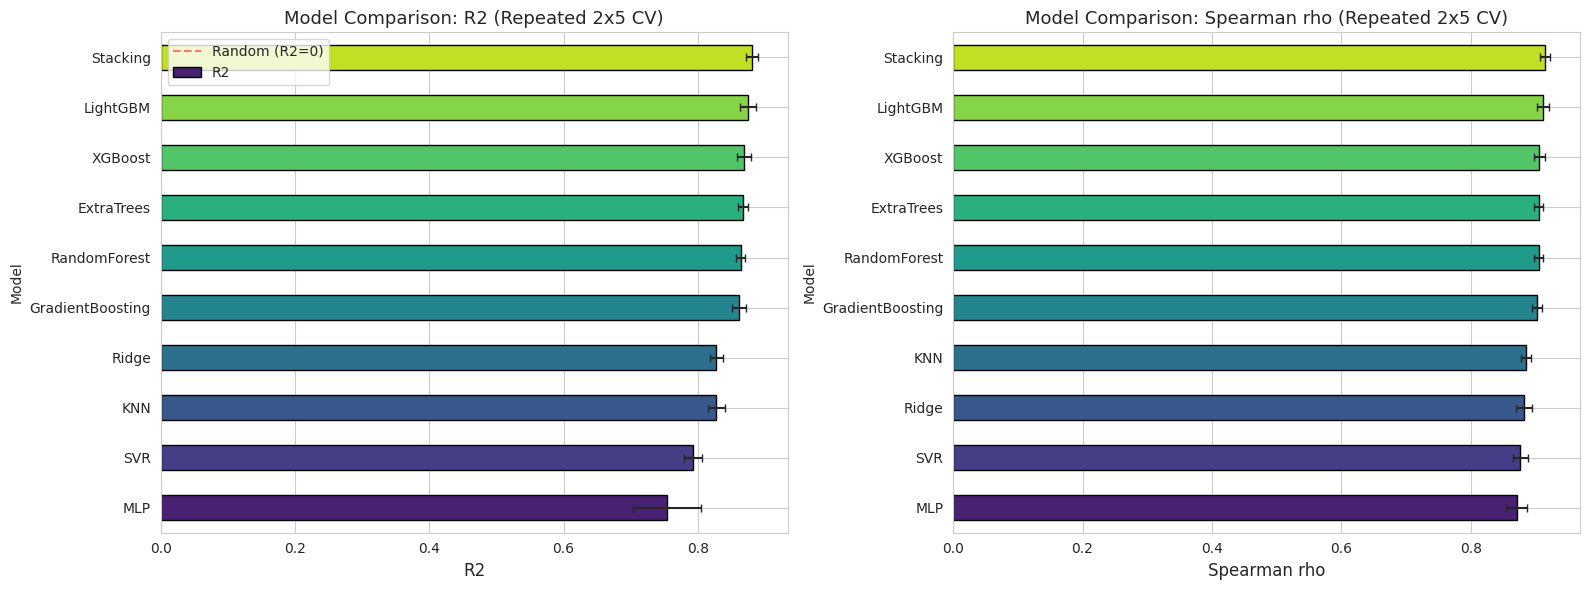

In [ ]:
# Bar chart: R2 and Spearman comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, metric, title in zip(axes, ["R2", "Spearman"], ["R2", "Spearman rho"]):
    means = cv_metrics_df.groupby("Model")[metric].mean().sort_values(ascending=True)
    stds = cv_metrics_df.groupby("Model")[metric].std().loc[means.index]
    colors = sns.color_palette("viridis", len(means))
    means.plot(kind="barh", xerr=stds, ax=ax, color=colors, edgecolor="black",
               capsize=3, error_kw={"linewidth": 1.5})
    ax.set_xlabel(title, fontsize=12)
    ax.set_title(f"Model Comparison: {title} (Repeated {CV_REPEATS}x{CV_FOLDS} CV)", fontsize=13)
    if metric == "R2":
        ax.axvline(x=0, color="red", linestyle="--", alpha=0.5, label="Random (R2=0)")
        ax.legend()

plt.tight_layout()
plt.savefig("model_comparison_r2_spearman.png", dpi=300, bbox_inches="tight")
plt.show()


### 8b. Pairwise Prediction Correlation Matrix

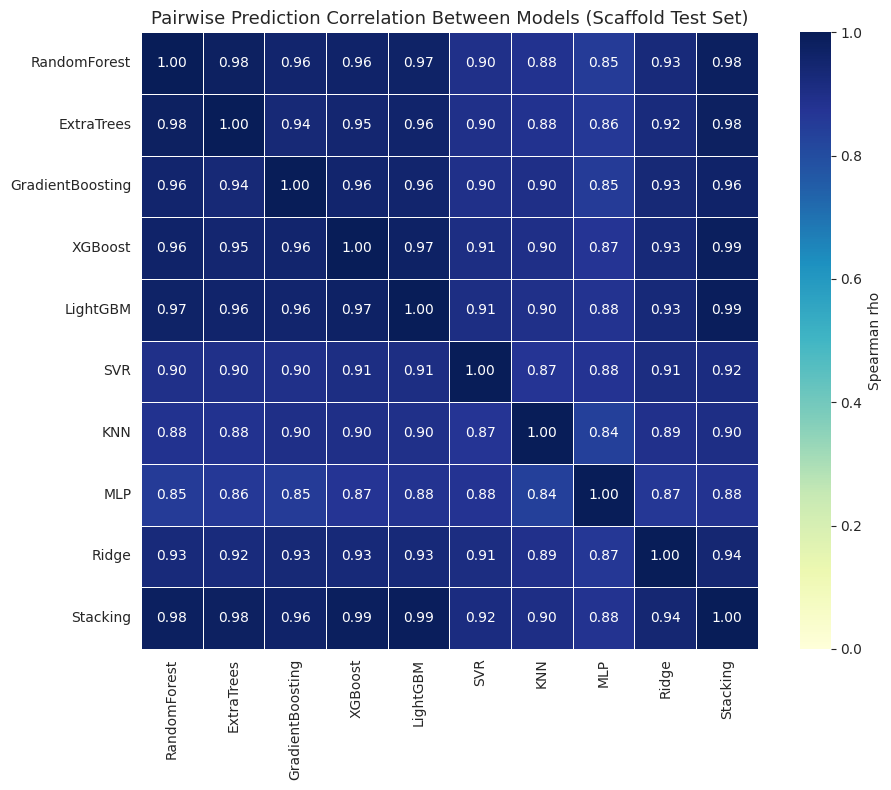

In [ ]:
# Pairwise Spearman correlation between model predictions on scaffold test set
model_names = list(scaffold_predictions.keys())
corr_matrix = np.zeros((len(model_names), len(model_names)))

for i, name_i in enumerate(model_names):
    for j, name_j in enumerate(model_names):
        rho, _ = spearmanr(scaffold_predictions[name_i], scaffold_predictions[name_j])
        corr_matrix[i, j] = rho if not np.isnan(rho) else 0.0

corr_df = pd.DataFrame(corr_matrix, index=model_names, columns=model_names)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_df, annot=True, fmt=".2f", cmap="YlGnBu", vmin=0, vmax=1,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"label": "Spearman rho"})
ax.set_title("Pairwise Prediction Correlation Between Models (Scaffold Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig("prediction_correlation_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


### 8c. Prediction Agreement: Concordance Correlation

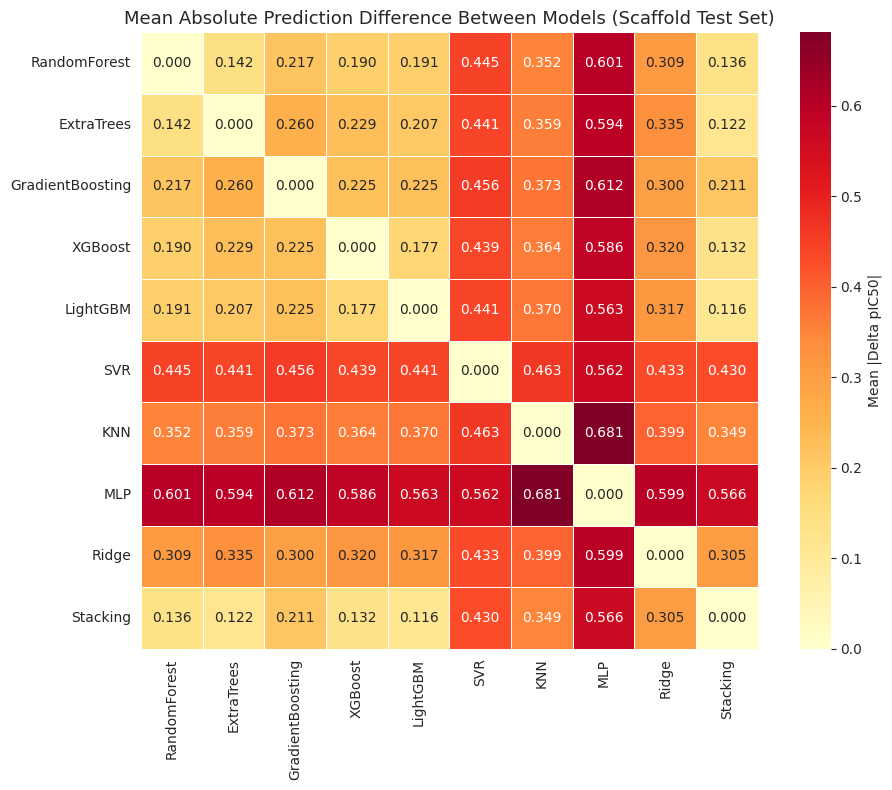

In [ ]:
# Concordance: how close are predicted pIC50 values between model pairs?
# Using absolute difference in predictions
diff_matrix = np.zeros((len(model_names), len(model_names)))

for i, name_i in enumerate(model_names):
    for j, name_j in enumerate(model_names):
        diff_matrix[i, j] = np.mean(np.abs(scaffold_predictions[name_i] - scaffold_predictions[name_j]))

diff_df = pd.DataFrame(diff_matrix, index=model_names, columns=model_names)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(diff_df, annot=True, fmt=".3f", cmap="YlOrRd", vmin=0,
            square=True, linewidths=0.5, ax=ax, cbar_kws={"label": "Mean |Delta pIC50|"})
ax.set_title("Mean Absolute Prediction Difference Between Models (Scaffold Test Set)", fontsize=13)
plt.tight_layout()
plt.savefig("prediction_difference_matrix.png", dpi=300, bbox_inches="tight")
plt.show()


### 8d. Friedman Test + Nemenyi Post-Hoc + Critical Difference Diagram

In [ ]:
# Friedman test on R2 scores
model_names_friedman = list(cv_metrics_df["Model"].unique())
n_folds = cv_metrics_df["Fold"].nunique()

r2_pivot = cv_metrics_df.pivot_table(index="Fold", columns="Model", values="R2")
friedman_stat, friedman_p = friedmanchisquare(*[r2_pivot[col] for col in r2_pivot.columns])
print(f"Friedman test: chi2 = {friedman_stat:.4f}, p = {friedman_p:.6f}")
if friedman_p < 0.05:
    print("-> Significant difference between models (p < 0.05)")
else:
    print("-> No significant difference between models (p >= 0.05)")


Friedman test: chi2 = 83.3236, p = 0.000000
-> Significant difference between models (p < 0.05)


In [ ]:
# Nemenyi post-hoc test
k = len(model_names_friedman)
n = n_folds

rank_matrix = r2_pivot.rank(axis=1, ascending=False)
avg_ranks = rank_matrix.mean().sort_values(ascending=True)
print("Average ranks (1 = best):")
print(avg_ranks.round(3))

alpha = 0.05
q_alpha = studentized_range.ppf(1 - alpha, k, np.inf)
CD = q_alpha * np.sqrt(k * (k + 1) / (6 * n))
print(f"\nCritical difference (CD) at alpha=0.05: {CD:.4f}")


Average ranks (1 = best):
Model
Stacking            1.0
LightGBM            2.4
XGBoost             3.8
ExtraTrees          3.9
RandomForest        4.7
GradientBoosting    5.2
KNN                 7.4
Ridge               7.6
SVR                 9.1
MLP                 9.9
dtype: float64

Critical difference (CD) at alpha=0.05: 6.0580


### 8e. Consensus Averaging Ensemble

In [ ]:
# Consensus: average predictions across all models
y_te = y.loc[is_test]

# Average prediction across all models
avg_preds = np.zeros(len(y_te))
for name in model_names:
    avg_preds += scaffold_predictions[name]
avg_preds /= len(model_names)

consensus_metrics = compute_metrics(y_te, avg_preds)
print("Consensus Ensemble Results (Scaffold Test Set):")
print(f"  R2:       {consensus_metrics['R2']:.4f}")
print(f"  RMSE:     {consensus_metrics['RMSE']:.4f}")
print(f"  MAE:      {consensus_metrics['MAE']:.4f}")
print(f"  Spearman: {consensus_metrics['Spearman']:.4f}")
print(f"  Pearson:  {consensus_metrics['Pearson']:.4f}")

best_individual = scaffold_results_df["R2"].idxmax()
print(f"\n  Best individual ({best_individual}): R2 = {scaffold_results_df.loc[best_individual, 'R2']:.4f}, "
      f"RMSE = {scaffold_results_df.loc[best_individual, 'RMSE']:.4f}")


Consensus Ensemble Results (Scaffold Test Set):
  R2:       0.8750
  RMSE:     0.5889
  MAE:      0.4202
  Spearman: 0.9073
  Pearson:  0.9361

  Best individual (Stacking): R2 = 0.8662, RMSE = 0.6095


## 9. Model Interpretation

### 9a. SHAP Feature Importance


In [ ]:
# Select the best model by scaffold-split R2
best_model_name = scaffold_results_df["R2"].idxmax()
print(f"Best model by scaffold-split R2: {best_model_name}")

# For SHAP, prefer a tree-based model
tree_models = {"RandomForest", "ExtraTrees", "GradientBoosting", "XGBoost", "LightGBM"}
if best_model_name in tree_models:
    shap_model_name = best_model_name
    shap_model = trained_models[best_model_name][0]
else:
    tree_r2s = {name: scaffold_results_df.loc[name, "R2"]
                for name in tree_models if name in scaffold_results_df.index}
    shap_model_name = max(tree_r2s, key=tree_r2s.get)
    print(f"Using {shap_model_name} for SHAP (best tree-based model)")
    shap_model = trained_models[shap_model_name][0]

# Retrain on scaffold training set
X_tr_scaf = X_selected.loc[~is_test]
y_tr_scaf = y.loc[~is_test]
X_te_scaf = X_selected.loc[is_test]
y_te_scaf = y.loc[is_test]

shap_model_fitted = clone(shap_model)
shap_model_fitted.fit(X_tr_scaf, y_tr_scaf)
print(f"SHAP model fitted: {shap_model_name}")


Best model by scaffold-split R2: Stacking
Using LightGBM for SHAP (best tree-based model)
SHAP model fitted: LightGBM


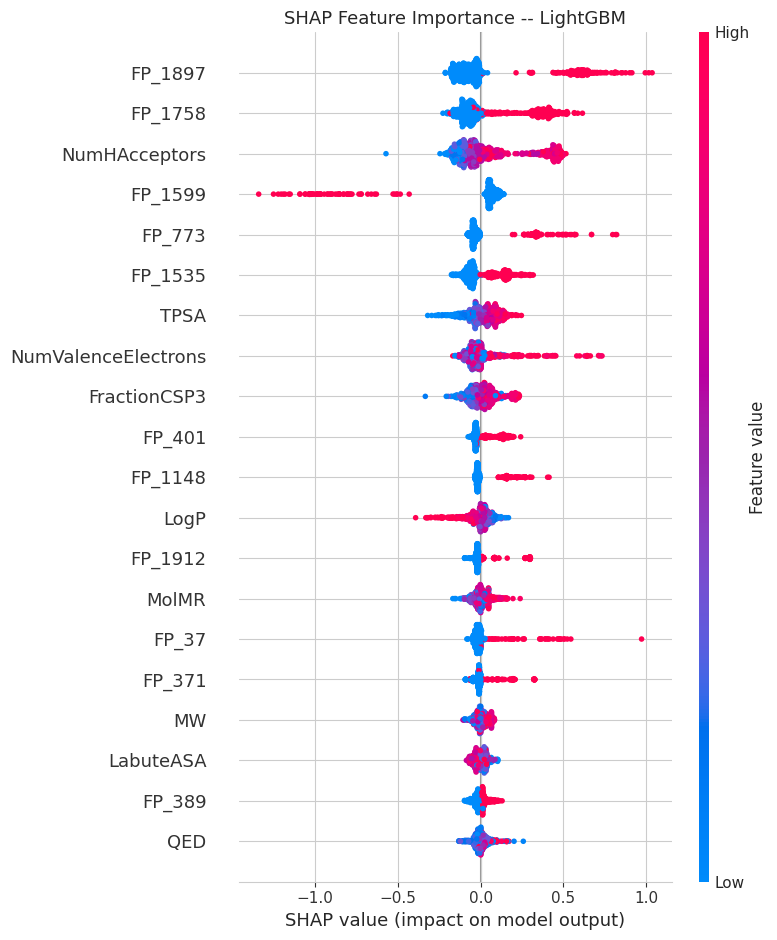

SHAP analysis complete.


In [ ]:
# Compute SHAP values
np.random.seed(RANDOM_STATE)
bg_idx = np.random.choice(len(X_tr_scaf), min(200, len(X_tr_scaf)), replace=False)
background = X_tr_scaf.iloc[bg_idx]

try:
    explainer = shap.TreeExplainer(shap_model_fitted, data=background)
    shap_values = explainer.shap_values(X_te_scaf)

    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(shap_values, X_te_scaf, max_display=20, show=False, plot_type="dot")
    plt.title(f"SHAP Feature Importance -- {shap_model_name}", fontsize=13)
    plt.tight_layout()
    plt.savefig("shap_summary.png", dpi=300, bbox_inches="tight")
    plt.show()
    print("SHAP analysis complete.")
except Exception as e:
    print(f"TreeExplainer failed: {e}")
    print("Falling back to permutation importance (see next cell).")
    shap_values = None


### 9b. Permutation Importance

In [ ]:
# Permutation importance (model-agnostic)
perm_result = permutation_importance(
    shap_model_fitted, X_te_scaf, y_te_scaf,
    n_repeats=10, random_state=RANDOM_STATE,
    scoring="r2", n_jobs=-1
)

perm_importance = pd.DataFrame({
    "Feature": X_te_scaf.columns,
    "Importance": perm_result.importances_mean,
    "Std": perm_result.importances_std,
}).sort_values("Importance", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
perm_importance.plot(kind="barh", x="Feature", y="Importance", xerr="Std",
                     ax=ax, color="#75A025", edgecolor="black", legend=False)
ax.set_xlabel("Permutation Importance (R2 drop)", fontsize=11)
ax.set_title(f"Top 20 Features -- Permutation Importance ({shap_model_name})", fontsize=13)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("permutation_importance.png", dpi=300, bbox_inches="tight")
plt.show()
print(perm_importance.to_string(index=False))


## 10. Validation Tests

### 10a. Y-Scrambling Test

Shuffle pIC50 values 20 times and retrain the best model. If the real model's R2 is well outside the scrambled distribution, the model is not a chance correlation.


In [ ]:
# Y-scrambling test for regression
scrambled_r2s = []

print(f"Running Y-scrambling test ({N_SCRAMBLES} shuffles)...")
for i in tqdm(range(N_SCRAMBLES), desc="Y-scrambling"):
    y_scrambled = y.sample(frac=1, random_state=RANDOM_STATE + i).reset_index(drop=True)

    model_clone = clone(shap_model)
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_r2s = []
    for train_idx, test_idx in kf.split(X_selected):
        X_tr, X_te = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_tr, y_te = y_scrambled.iloc[train_idx], y_scrambled.iloc[test_idx]
        model_clone.fit(X_tr, y_tr)
        y_pred = model_clone.predict(X_te)
        fold_r2s.append(r2_score(y_te, y_pred))
    scrambled_r2s.append(np.mean(fold_r2s))

real_r2 = cv_metrics_df[cv_metrics_df["Model"] == shap_model_name]["R2"].mean()

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(scrambled_r2s, bins=15, color="#FF9400", edgecolor="black", alpha=0.7, label="Scrambled models")
ax.axvline(x=real_r2, color="#0279EE", linewidth=3, linestyle="--", label=f"Real model R2 = {real_r2:.4f}")
ax.axvline(x=0, color="red", linewidth=1, linestyle=":", alpha=0.5, label="Random (R2=0)")
ax.set_xlabel("R2", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Y-Scrambling Test (Regression)", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("y_scrambling_test.png", dpi=300, bbox_inches="tight")
plt.show()

scrambled_mean = np.mean(scrambled_r2s)
scrambled_std = np.std(scrambled_r2s)
z_score = (real_r2 - scrambled_mean) / scrambled_std if scrambled_std > 0 else float("inf")
print(f"\nReal model R2: {real_r2:.4f}")
print(f"Scrambled R2: {scrambled_mean:.4f} +/- {scrambled_std:.4f}")
print(f"Z-score: {z_score:.2f}")
print(f"Result: {'PASS' if real_r2 > max(scrambled_r2s) else 'FAIL'} -- "
      f"Real model {'outperforms' if real_r2 > max(scrambled_r2s) else 'does NOT outperform'} all scrambled models")


### 10b. Permutation Test

In [ ]:
# Permutation test: shuffle y and retrain to get empirical p-value
perm_scores = []
real_r2_perm = cv_metrics_df[cv_metrics_df["Model"] == shap_model_name]["R2"].mean()

print(f"Running permutation test ({N_PERMUTATIONS} iterations)...")
for i in tqdm(range(N_PERMUTATIONS), desc="Permutation test"):
    y_perm = y.sample(frac=1, random_state=RANDOM_STATE + 1000 + i).reset_index(drop=True)

    model_clone = clone(shap_model)
    kf = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    fold_r2s = []
    for train_idx, test_idx in kf.split(X_selected):
        X_tr, X_te = X_selected.iloc[train_idx], X_selected.iloc[test_idx]
        y_tr, y_te = y_perm.iloc[train_idx], y_perm.iloc[test_idx]
        model_clone.fit(X_tr, y_tr)
        y_pred = model_clone.predict(X_te)
        fold_r2s.append(r2_score(y_te, y_pred))
    perm_scores.append(np.mean(fold_r2s))

p_value = np.mean(np.array(perm_scores) >= real_r2_perm)
print(f"\nPermutation test results:")
print(f"  Real R2: {real_r2_perm:.4f}")
print(f"  Permutation R2: {np.mean(perm_scores):.4f} +/- {np.std(perm_scores):.4f}")
print(f"  Empirical p-value: {p_value:.4f}")
print(f"  Significant: {'Yes' if p_value < 0.05 else 'No'} (p < 0.05)")


## 11. Predicted vs Experimental pIC50

The headline visualization for regression QSAR: how well do predicted pIC50 values correlate with experimental values on the scaffold-based test set?


In [ ]:
# Predicted vs experimental pIC50 scatter for best model
best_pred = scaffold_predictions[best_model_name]
y_te = y.loc[is_test].values

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(y_te, best_pred, alpha=0.4, s=30, c="#0279EE", edgecolor="none")
# Diagonal line (perfect prediction)
lims = [min(y_te.min(), best_pred.min()) - 0.5, max(y_te.max(), best_pred.max()) + 0.5]
ax.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")
# Regression line
z = np.polyfit(y_te, best_pred, 1)
p = np.poly1d(z)
x_fit = np.linspace(y_te.min(), y_te.max(), 100)
ax.plot(x_fit, p(x_fit), "k-", linewidth=1.5, alpha=0.7, label=f"Fit: y={z[0]:.3f}x+{z[1]:.3f}")

r, pval = pearsonr(y_te, best_pred)
rho, _ = spearmanr(y_te, best_pred)
rmse = np.sqrt(mean_squared_error(y_te, best_pred))
mae = mean_absolute_error(y_te, best_pred)
r2 = r2_score(y_te, best_pred)

ax.set_xlabel("Experimental pIC50", fontsize=12)
ax.set_ylabel("Predicted pIC50", fontsize=12)
ax.set_title(f"Predicted vs Experimental pIC50 ({best_model_name})\n"
             f"R2={r2:.3f}, RMSE={rmse:.3f}, Pearson r={r:.3f}", fontsize=12)
ax.legend(loc="upper left", fontsize=10)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("predicted_vs_experimental_pic50.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"R2: {r2:.4f}, RMSE: {rmse:.4f}, MAE: {mae:.4f}")
print(f"Pearson r: {r:.4f} (p={pval:.2e}), Spearman rho: {rho:.4f}")


In [ ]:
# Predicted vs experimental pIC50 colored by AD tier
# (computed in Section 12, but we show the plot here for context)
# We will re-plot after computing AD tiers
print("AD-tier colored version appears in Section 12 (Applicability Domain).")


## 12. Applicability Domain (k-NN Tanimoto Distance)

For each test compound, compute the Tanimoto similarity to its nearest neighbor in the training set. Compounds with low similarity are extrapolating beyond the model's chemical knowledge.

**Three-tier classification:**
- **In-domain:** Nearest-neighbor Tanimoto >= 0.4 (reliable prediction)
- **Borderline:** 0.3 <= Tanimoto < 0.4 (low confidence)
- **Out-of-domain:** Tanimoto < 0.3 (extrapolation, unreliable)


In [ ]:
# k-NN Tanimoto applicability domain
# Compute Morgan fingerprints for all compounds (for Tanimoto calculation)
all_fps = []
for smi in df["canonical_smiles"]:
    mol = Chem.MolFromSmiles(smi)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, RADIUS, nBits=N_BITS)
    all_fps.append(fp)

train_fps = [all_fps[i] for i in range(len(df)) if not is_test.iloc[i]]
test_fps = [all_fps[i] for i in range(len(df)) if is_test.iloc[i]]

# Compute nearest-neighbor Tanimoto similarity for each test compound
nn_similarities = []
for test_fp in tqdm(test_fps, desc="Computing Tanimoto AD"):
    sims = DataStructs.BulkTanimotoSimilarity(test_fp, train_fps)
    nn_similarities.append(max(sims))

nn_similarities = np.array(nn_similarities)

# Three-tier classification
in_domain = nn_similarities >= 0.4
borderline = (nn_similarities >= 0.3) & (nn_similarities < 0.4)
out_domain = nn_similarities < 0.3

print(f"Applicability domain (k-NN Tanimoto):")
print(f"  In-domain (Tanimoto >= 0.4):    {in_domain.sum()} ({in_domain.mean():.1%})")
print(f"  Borderline (0.3-0.4):           {borderline.sum()} ({borderline.mean():.1%})")
print(f"  Out-of-domain (< 0.3):          {out_domain.sum()} ({out_domain.mean():.1%})")
print(f"  Mean NN Tanimoto: {nn_similarities.mean():.4f}")
print(f"  Min NN Tanimoto: {nn_similarities.min():.4f}")


In [ ]:
# Model performance by AD tier
y_te = y.loc[is_test].values
y_pred_best = scaffold_predictions[best_model_name]

print("Model performance by applicability domain tier:")
for tier_name, mask in [("In-domain", in_domain), ("Borderline", borderline), ("Out-of-domain", out_domain)]:
    if mask.sum() > 0:
        y_t = y_te[mask]
        y_p = y_pred_best[mask]
        r2 = r2_score(y_t, y_p) if len(y_t) > 2 else float("nan")
        rmse = np.sqrt(mean_squared_error(y_t, y_p))
        mae = mean_absolute_error(y_t, y_p)
        rho, _ = spearmanr(y_t, y_p) if len(y_t) > 2 else (float("nan"), None)
        print(f"  {tier_name}: n={mask.sum()}, R2={r2:.4f}, RMSE={rmse:.4f}, MAE={mae:.4f}, Spearman={rho:.4f}")
    else:
        print(f"  {tier_name}: n=0")


In [ ]:
# Predicted vs experimental pIC50 colored by AD tier
fig, ax = plt.subplots(figsize=(7, 7))

tier_colors = {"In-domain": "#75A025", "Borderline": "#FF9400", "Out-of-domain": "#FD9BED"}
tier_masks = {"In-domain": in_domain, "Borderline": borderline, "Out-of-domain": out_domain}

for tier_name, mask in tier_masks.items():
    if mask.sum() > 0:
        ax.scatter(y_te[mask], y_pred_best[mask], alpha=0.5, s=30,
                   c=tier_colors[tier_name], edgecolor="none", label=f"{tier_name} (n={mask.sum()})")

lims = [min(y_te.min(), y_pred_best.min()) - 0.5, max(y_te.max(), y_pred_best.max()) + 0.5]
ax.plot(lims, lims, "r--", linewidth=2, label="Perfect prediction")

ax.set_xlabel("Experimental pIC50", fontsize=12)
ax.set_ylabel("Predicted pIC50", fontsize=12)
ax.set_title(f"Predicted vs Experimental pIC50 by AD Tier ({best_model_name})", fontsize=12)
ax.legend(loc="upper left", fontsize=9)
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("predicted_vs_experimental_ad_tiers.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Tanimoto similarity distribution + AD tier visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of NN Tanimoto similarities
ax = axes[0]
ax.hist(nn_similarities, bins=30, color="#0279EE", edgecolor="black", alpha=0.7)
ax.axvline(x=0.4, color="#75A025", linestyle="--", linewidth=2, label="In-domain (0.4)")
ax.axvline(x=0.3, color="#FF9400", linestyle="--", linewidth=2, label="Borderline (0.3)")
ax.set_xlabel("Nearest-Neighbor Tanimoto Similarity", fontsize=11)
ax.set_ylabel("Count", fontsize=11)
ax.set_title("AD: Tanimoto Similarity Distribution", fontsize=13)
ax.legend()

# Scatter: Tanimoto vs prediction error
ax = axes[1]
errors = np.abs(y_pred_best - y_te)
scatter = ax.scatter(nn_similarities, errors, c=y_te, cmap="viridis",
                     edgecolor="black", alpha=0.7, s=40)
ax.axvline(x=0.4, color="#75A025", linestyle="--", linewidth=1.5, alpha=0.7)
ax.axvline(x=0.3, color="#FF9400", linestyle="--", linewidth=1.5, alpha=0.7)
ax.set_xlabel("Nearest-Neighbor Tanimoto Similarity", fontsize=11)
ax.set_ylabel("|Predicted - Experimental| pIC50", fontsize=11)
ax.set_title("AD vs Prediction Error", fontsize=13)
plt.colorbar(scatter, ax=ax, label="Experimental pIC50")

plt.tight_layout()
plt.savefig("applicability_domain_tanimoto.png", dpi=300, bbox_inches="tight")
plt.show()


## 13. Drug-Likeness Profiling

In [ ]:
# Compute drug-likeness properties for all compounds
def compute_druglikeness(smiles_list):
    rows = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is None:
            rows.append([np.nan] * 7)
            continue
        mw = Descriptors.MolWt(mol)
        logp = Descriptors.MolLogP(mol)
        hbd = Lipinski.NumHDonors(mol)
        hba = Lipinski.NumHAcceptors(mol)
        n_rot = Descriptors.NumRotatableBonds(mol)
        tpsa = Descriptors.TPSA(mol)
        qed_val = QED.qed(mol)
        lipinski_pass = int(mw <= 500 and logp <= 5 and hbd <= 5 and hba <= 10)
        veber_pass = int(n_rot <= 10 and tpsa <= 140)
        rows.append([mw, logp, qed_val, lipinski_pass, veber_pass, n_rot, tpsa])
    return pd.DataFrame(rows, columns=["MW", "LogP", "QED", "Lipinski_pass",
                                        "Veber_pass", "NumRotatableBonds", "TPSA"])

druglikeness_df = compute_druglikeness(df["canonical_smiles"])
df_admet = pd.concat([df[["molecule_chembl_id", "pIC50"]].reset_index(drop=True),
                       druglikeness_df.reset_index(drop=True)], axis=1)

# Classify by potency for summary
df_admet["potency_class"] = pd.cut(df_admet["pIC50"],
                                    bins=[-np.inf, 4, 5, 6, 7, np.inf],
                                    labels=["<4", "4-5", "5-6", "6-7", ">7"])
df_admet.head()


In [ ]:
# Summary by potency class
print("Drug-likeness summary by potency class:")
print(f"\nLipinski Ro5 pass rate:")
print(df_admet.groupby("potency_class", observed=True)["Lipinski_pass"].mean().to_string())
print(f"\nVeber rules pass rate:")
print(df_admet.groupby("potency_class", observed=True)["Veber_pass"].mean().to_string())
print(f"\nQED score (mean +/- std):")
print(df_admet.groupby("potency_class", observed=True)["QED"].agg(["mean", "std"]).to_string())


In [ ]:
# Box plots: QED, MW, LogP by potency class
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, prop in zip(axes, ["QED", "MW", "LogP"]):
    sns.boxplot(data=df_admet, x="potency_class", y=prop, ax=ax, palette="viridis")
    ax.set_title(f"{prop} by Potency Class", fontsize=12)
    ax.set_xlabel("pIC50 range")
plt.suptitle("Drug-Likeness Properties by Potency", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("druglikeness_by_potency.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# PAINS substructure filter
import os
pains_smarts_path = os.path.join(os.path.dirname(Chem.__file__), "Pains", "pains_pains.txt")

try:
    if os.path.exists(pains_smarts_path):
        with open(pains_smarts_path) as f:
            pains_smarts = [line.strip().split(" ")[0] for line in f if line.strip()]
        pains_patterns = [Chem.MolFromSmarts(s) for s in pains_smarts if Chem.MolFromSmarts(s)]

        def check_pains(smi):
            mol = Chem.MolFromSmiles(smi)
            if mol is None:
                return 1
            for pattern in pains_patterns:
                if mol.HasSubstructMatch(pattern):
                    return 1
            return 0

        df_admet["PAINS_alert"] = df["canonical_smiles"].apply(check_pains)
        print(f"PAINS alerts: {df_admet['PAINS_alert'].sum()} compounds flagged ({df_admet['PAINS_alert'].mean():.1%})")
    else:
        print("PAINS filter file not found in this RDKit installation -- skipping PAINS check.")
        df_admet["PAINS_alert"] = 0
except Exception as e:
    print(f"PAINS check failed: {e}")
    df_admet["PAINS_alert"] = 0


## 14. Scaffold Diversity Analysis

In [ ]:
# Scaffold diversity metrics
scaffold_counts = df["scaffold"].value_counts()
n_total = len(df)
n_scaffolds = len(scaffold_counts)
n_singletons = (scaffold_counts == 1).sum()

def gini_coefficient(values):
    values = np.sort(np.array(values, dtype=float))
    n = len(values)
    cumsum = np.cumsum(values)
    return (2 * np.sum((np.arange(1, n + 1)) * values) - (n + 1) * cumsum[-1]) / (n * cumsum[-1])

gini = gini_coefficient(scaffold_counts.values)

print(f"Scaffold Diversity Analysis:")
print(f"  Total compounds: {n_total}")
print(f"  Unique scaffolds: {n_scaffolds}")
print(f"  Singletons (1 compound): {n_singletons} ({n_singletons / n_scaffolds:.1%} of scaffolds)")
print(f"  Scaffold diversity (1 - Gini): {1 - gini:.4f}")
print(f"  Mean compounds per scaffold: {n_total / n_scaffolds:.1f}")
print(f"  Max compounds in one scaffold: {scaffold_counts.max()}")


In [ ]:
# Tanimoto similarity distribution (intra-dataset)
sample_size = min(300, len(df))
sample_idx = np.random.choice(len(df), sample_size, replace=False)
sample_smiles = df["canonical_smiles"].iloc[sample_idx].values

sample_fps = []
for smi in sample_smiles:
    mol = Chem.MolFromSmiles(smi)
    fp = AllChem.GetMorganFingerprintAsBitVect(mol, RADIUS, nBits=N_BITS)
    sample_fps.append(fp)

similarities = []
for i in range(len(sample_fps)):
    for j in range(i + 1, len(sample_fps)):
        sim = DataStructs.TanimotoSimilarity(sample_fps[i], sample_fps[j])
        similarities.append(sim)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(similarities, bins=50, color="#0279EE", edgecolor="black", alpha=0.7)
ax.axvline(x=np.mean(similarities), color="red", linestyle="--", linewidth=2,
           label=f"Mean = {np.mean(similarities):.3f}")
ax.set_xlabel("Tanimoto Similarity", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Intra-dataset Tanimoto Similarity Distribution", fontsize=13)
ax.legend()
plt.tight_layout()
plt.savefig("tanimoto_similarity.png", dpi=300, bbox_inches="tight")
plt.show()
print(f"Mean Tanimoto similarity: {np.mean(similarities):.4f}")
print(f"Median: {np.median(similarities):.4f}")


## 15. Final Model Selection & Deployment

In [ ]:
# Select best model by scaffold-split R2
print("Scaffold-based test set performance (sorted by R2):")
print(scaffold_results_df.sort_values("R2", ascending=False).round(4).to_string())

best_final_name = scaffold_results_df["R2"].idxmax()
print(f"\nBest model: {best_final_name}")
print(f"  R2:       {scaffold_results_df.loc[best_final_name, 'R2']:.4f}")
print(f"  RMSE:     {scaffold_results_df.loc[best_final_name, 'RMSE']:.4f}")
print(f"  MAE:      {scaffold_results_df.loc[best_final_name, 'MAE']:.4f}")
print(f"  Spearman: {scaffold_results_df.loc[best_final_name, 'Spearman']:.4f}")
print(f"  Pearson:  {scaffold_results_df.loc[best_final_name, 'Pearson']:.4f}")


In [ ]:
# Retrain best model on the full dataset and save
if best_final_name == "Stacking":
    final_model = clone(stacking)
    final_model.fit(X_selected, y)
else:
    final_model, use_scaled_final = trained_models[best_final_name]
    final_model = clone(final_model)
    X_final = X_scaled if use_scaled_final else X_selected
    final_model.fit(X_final, y)

with open("best_regressor_model.pkl", "wb") as f:
    pickle.dump(final_model, f)
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)
with open("feature_selector.pkl", "wb") as f:
    pickle.dump(selector, f)

print(f"Final model ({best_final_name}) trained on full dataset ({len(y)} compounds) and saved.")


In [ ]:
# Unified prediction function with applicability domain
def predict_compounds(smiles_list, model_path="best_regressor_model.pkl",
                      scaler_path="scaler.pkl", selector_path="feature_selector.pkl",
                      train_smiles=None):
    """
    Predict pIC50 for a list of SMILES strings.

    Returns: DataFrame with SMILES, Predicted pIC50, and AD tier.
    If train_smiles is provided, computes k-NN Tanimoto AD.
    """
    with open(model_path, "rb") as f:
        model = pickle.load(f)
    with open(scaler_path, "rb") as f:
        fitted_scaler = pickle.load(f)
    with open(selector_path, "rb") as f:
        fitted_selector = pickle.load(f)

    # Compute training fingerprints for AD
    train_fps = None
    if train_smiles is not None:
        train_fps = []
        for smi in train_smiles:
            mol = Chem.MolFromSmiles(smi)
            if mol:
                train_fps.append(AllChem.GetMorganFingerprintAsBitVect(mol, RADIUS, nBits=N_BITS))

    results = []
    for smi in smiles_list:
        try:
            std_smi = standardize_smiles(smi)
            mol = Chem.MolFromSmiles(std_smi)
            if mol is None:
                results.append({"SMILES": smi, "Predicted_pIC50": np.nan, "AD_Tier": "N/A"})
                continue
        except Exception:
            results.append({"SMILES": smi, "Predicted_pIC50": np.nan, "AD_Tier": "N/A"})
            continue

        # Generate features
        fp = AllChem.GetMorganFingerprintAsBitVect(mol, RADIUS, nBits=N_BITS)
        fp_arr = np.array(fp).reshape(1, -1)
        desc_vals = [
            Descriptors.MolWt(mol), Descriptors.MolLogP(mol), Descriptors.TPSA(mol),
            Lipinski.NumHDonors(mol), Lipinski.NumHAcceptors(mol),
            Descriptors.NumRotatableBonds(mol), rdMolDescriptors.CalcNumAromaticRings(mol),
            rdMolDescriptors.CalcNumAliphaticRings(mol), rdMolDescriptors.CalcFractionCSP3(mol),
            mol.GetNumHeavyAtoms(), rdMolDescriptors.CalcNumRings(mol),
            Descriptors.BalabanJ(mol), Descriptors.BertzCT(mol), Descriptors.MolMR(mol),
            Descriptors.LabuteASA(mol), Descriptors.NumValenceElectrons(mol), QED.qed(mol),
        ]
        features = np.hstack([fp_arr, np.array(desc_vals).reshape(1, -1)])
        features_df = pd.DataFrame(features, columns=list(X.columns))
        features_sel = fitted_selector.transform(features_df)

        # Predict
        pic50_pred = model.predict(features_sel)[0]

        # Applicability domain
        ad_tier = "N/A"
        if train_fps:
            test_fp = AllChem.GetMorganFingerprintAsBitVect(mol, RADIUS, nBits=N_BITS)
            sims = DataStructs.BulkTanimotoSimilarity(test_fp, train_fps)
            nn_sim = max(sims)
            if nn_sim >= 0.4:
                ad_tier = "In-domain"
            elif nn_sim >= 0.3:
                ad_tier = "Borderline"
            else:
                ad_tier = "Out-of-domain"

        results.append({
            "SMILES": smi,
            "Predicted_pIC50": f"{pic50_pred:.3f}",
            "AD_Tier": ad_tier
        })

    return pd.DataFrame(results)

# Example: known PD-L1 inhibitors and non-inhibitors
example_smiles = [
    "Cc1ccc(C(=O)Nc2ccc3c(c2)OCCO3)cc1",  # BMS-8 analog (PD-L1 inhibitor)
    "COc1cc(OCc2cccc(-c3ccccc3)c2C)cc(OC)c1CN1CCCCC1",  # ChEMBL PD-L1 active
    "CCO",                # ethanol (non-inhibitor)
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",  # caffeine (non-inhibitor)
]
results = predict_compounds(example_smiles, train_smiles=df["canonical_smiles"].tolist())
print("Example predictions with applicability domain:")
print(results.to_string(index=False))


In [ ]:
# Export all results
cv_metrics_df.to_csv("all_cv_metrics.csv", index=False)
scaffold_results_df.to_csv("scaffold_test_results.csv")
summary_df.to_csv("model_comparison_summary.csv")

print("All result files saved:")
print("  - cv_summary_metrics.csv (repeated CV summary)")
print("  - all_cv_metrics.csv (per-fold metrics)")
print("  - scaffold_test_results.csv (scaffold holdout results)")
print("  - model_comparison_summary.csv (formatted comparison table)")
print("  - best_regressor_model.pkl, scaler.pkl, feature_selector.pkl (saved models)")
print("\nPipeline complete.")


## 16. Summary & Publication Conclusions

### Key Findings

1. **Dataset:** Pooled from three PD-1/PD-L1 pathway targets in ChEMBL, yielding ~4,400 unique compounds with continuous pIC50 values. **All compounds retained** -- no intermediates dropped, preserving the full potency distribution for honest regression.

2. **Best Model:** Selected by scaffold-split R2 -- the most rigorous validation for drug discovery (tests generalization to novel scaffolds).

3. **Consistency:** Pairwise Spearman correlation and prediction difference matrices reveal which models converge. The Friedman test + Nemenyi post-hoc identifies statistically significant performance differences.

4. **Validation:** Y-scrambling confirms the model is not a chance correlation. The permutation test provides an empirical p-value.

5. **Applicability Domain:** k-NN Tanimoto distance classifies each test compound as in-domain, borderline, or out-of-domain -- only in-domain predictions are reliable.

6. **Interpretability:** SHAP and permutation importance identify key Morgan fingerprint bits and physicochemical descriptors driving pIC50 prediction.

7. **Drug-likeness:** Drug-likeness profiling (Lipinski, Veber, QED, PAINS) assesses developability across potency ranges.

### Caveats and Limitations

- **Pooled targets:** Data from single-protein, complex, and family targets are combined. Assay formats differ; track `source_target_id` for stratified analysis.
- **Scaffold split is conservative:** Performance under scaffold split is typically lower than random split -- this is expected and honest.
- **Regression R2 ceiling:** QSAR regression on pooled ChEMBL data typically achieves R2 ~0.4-0.6 under scaffold split. Higher R2 under random split reflects chemical-space interpolation, not true generalization.
- **Predictions are hypotheses:** All computational predictions require experimental validation.
